In [5]:
import os
import sys
from textwrap import wrap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

os.chdir("/home/kaariaa3/mscthesis/")
sys.path.append("./src/")  # Add parent directory to path

import json
import pandas as pd

from utils.helpers import parse_output

from utils.constants import DEFAULT_AUGMENT_RESULT

from utils.prompts import (
    JUDGE_SYSTEM_PROMPT,
    JUDGE_TEMPLATE,
    AUGMENT_SYSTEM_PROMPT,
    AUGMENT_TEMPLATE,
)

def wrap_text(text, num_chars):
    return '\n'.join(wrap(text, num_chars))

In [7]:
LABELS = ["yes", "no"] # Labels per column
EVAL_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)']
PRED_COLS = ['augmentedProblemDescription', 'augmentedExampleSolution']
PLOT_COLS = ['The exercise description matched the selected theme (Yes/Partially/No)',
       'The exercise description matched the selected topic (Yes/Partially/No)',
       #'The exercise description matched the selected concept (Yes/No)'
            ]

def plot_distributions(df, axes, labels=LABELS, cols=PLOT_COLS):
    fig = axes[0].figure

    for i, col in enumerate(cols):
        sns.countplot(x=df[col], order=labels, ax=axes[i])
        axes[i].set_title(wrap_text(f"{col.upper()}", 20))
        axes[i].set_xlabel("")

    return fig, axes

In [10]:
# Load data
datapath = r"./data/batch_16632426_result.csv"
augmented_data = pd.read_csv(datapath, sep=";")

# Remove erroneous examples
mask_no_errors = (augmented_data[PRED_COLS] != "\"PARSE ERROR\"").all(axis=1)
print("Error count: " + str(list(mask_no_errors).count(False)))

# Keep rows where evaluation columns are all "yes"
mask_all_yes = augmented_data[EVAL_COLS].eq("yes").all(axis=1)
print("Count of rows dropped: " + str(list(mask_all_yes).count(False)))

augmented_data = augmented_data[mask_no_errors & mask_all_yes].reset_index()

Error count: 0
Count of rows dropped: 0


,index,title,problemDescription,exampleSolution,starterCode,tests,theme,topic,concept,difficulty,...,The exercise description matched the selected theme (Yes/Partially/No),The exercise description matched the selected topic (Yes/Partially/No),The exercise description matched the selected concept (Yes/No),Included concepts that were too advanced (Yes/No)\n,The exercise difficulty matched the selected difficulty (Too easy/Okay/Too difficult),Shallow vs deep personalization (Deep/Shallow/Unsure),Open field,prompt,augmentedProblemDescription,augmentedExampleSolution
0,0,Agatha Christie's Novel Ratings,"Agatha Christie, the famous novelist, has a ra...","{'code': ""import 'dart:io'; main() { print(...","{'code': ""import 'dart:io'; main() { }""}","{'testCode': ""import 'dart:async'; import 'pa...",literature,Agatha Christie,conditional statements,advanced,...,yes,yes,yes,no,too easy,shallow,NaN,Rewrite the following programming exercise.\n\...,"""It's Christmas Eve and the family is hanging ...","{""code"": ""import 'dart:io'; main() { print('Wh..."
1,1,Painting Assessment,"In a painting class, the paintings are assesse...","{'code': ""import 'dart:io'; main() { print(...","{'code': ""import 'dart:io'; main() { }""}","{'testCode': ""import 'dart:async'; import 'pa...",handicrafts,painting,conditional statements,normal,...,yes,yes,yes,no,okay,shallow,NaN,Rewrite the following programming exercise.\n\...,"""In a camping trip, the campers are asked to r...","{""code"": ""import 'dart:io'; main() { bool run ..."
2,2,Lingonberry Sauce!,Write a program that asks the user for their f...,"{'code': ""import 'dart:io'; main() { print(...","{'code': ""import 'dart:io'; main() { }""}","{'testCode': ""import 'package:test/test.dart';...",food,Lingonberry sauce,user input,normal,...,yes,yes,yes,no,okay,shallow,NaN,Rewrite the following programming exercise.\n\...,"""Write a program that calculates and prints th...","{""code"": ""import 'dart:io'; main() { print('En..."
3,3,Mozart's Symphony,Write a program that asks the user for their f...,"{'code': ""import 'dart:io';main() { print('Wh...","{'code': ""import 'dart:io';main() {}""}","{'testCode': ""import 'package:test/test.dart';...",classical music,Wolfgang Amadeus Mozart,program output,normal,...,yes,yes,yes,no,okay,shallow,NaN,Rewrite the following programming exercise.\n\...,"""Write a program that asks the user for the nu...","{""code"": ""import 'dart:io';main() { print('Ho..."
4,4,Calculate Monopoly rent,"In Monopoly, the rent a player must pay when t...","{'code': ""import 'dart:io'; main() { var ho...","{'code': ""import 'dart:io'; main() { } ""}","{'testCode': ""import 'dart:async'; import 'pa...",board games,Monopoly,arithmetics,normal,...,yes,yes,yes,no,okay,deep,NaN,Rewrite the following programming exercise.\n\...,"""In a fish tank, the amount of food a fish own...","{""code"": ""import 'dart:io'; main() { var fish ..."


In [4]:
flag = True
if flag:
    first_occurrence_by_concept = [augmented_data["concept"].eq(concept).idxmax() for concept in augmented_data["concept"].unique()]
    for i in first_occurrence_by_concept:
        row = augmented_data.loc[i]
        
        print("Topic: " + row["topic"])
        print("Theme: " + row["theme"])
        print("Concept: " + row["concept"])
        print()
        print("Problem description: ", row["problemDescription"])
        print("Example solution: ", row["exampleSolution"])
        print()
        print("Augmented problem description: " + row["augmentedProblemDescription"])
        print()
        print("Augmented example solution: " + row["augmentedExampleSolution"])
        print()
        print("-------------------------------------------")
        print()

Topic: Agatha Christie
Theme: literature
Concept: conditional statements

Problem description:  Agatha Christie, the famous novelist, has a rating scale for her novels. The ratings are represented as numbers and are accompanied by the following textual descriptions:
<table>
<tr>
<th>Rating</th>
<th>Description</th>
</tr>
<tr>
<th>5</th>
<th>Masterpiece</th>
</tr>
<tr>
<th>4</th>
<th>Excellent</th>
</tr>
<tr>
<th>3</th>
<th>Good</th>
</tr>
<tr>
<th>2</th>
<th>Fair</th>
</tr>
<tr>
<th>1</th>
<th>Below Average</th>
</tr>
</table>
Write a program that asks the user for a number and prints the textual description related to that number. If the user enters any other number, the program should print the message <code>Invalid rating!</code>.

Below is an example of the expected operation of the program.

<pre>
What rating?
<b>&lt; 3</b>
Good
</pre>

Another example.

<pre>
What rating?
<b>&lt; 6</b>
Invalid rating!
</pre>
Example solution:  {'code': "import 'dart:io';  main() {   print('What r

In [5]:
# Set non-faithful instances to real column
augmented_data["problemDescription"] = augmented_data["augmentedProblemDescription"]
augmented_data["exampleSolution"] = augmented_data["augmentedExampleSolution"]

# Flip labels
augmented_data[EVAL_COLS[0]] = "no"
augmented_data[EVAL_COLS[1]] = "no"


# Drop last three columns: prompt, augmentedProblemDescription, augmentedExampleSolution
augmented_data = augmented_data.iloc[:, :-3]

In [6]:
# Load original dataset
orig = r"../../../data/complete_dataset.csv"
original_dataset = pd.read_csv(orig, sep=";")

# Remove rows with label 'partially'
mask_no_partially = (original_dataset[EVAL_COLS] != "partially").all(axis=1)
print("Count of rows with 'partially' labels: " + str(list(mask_no_partially).count(False)))
pruned = original_dataset[mask_no_partially].reset_index()

#concated = pd.concat([original_dataset, augmented_data], ignore_index=True).iloc[:,:-1]

concated_with_pruned = pd.concat([pruned, augmented_data], ignore_index=True).iloc[:,:-1]

Count of rows with 'partially' labels: 10


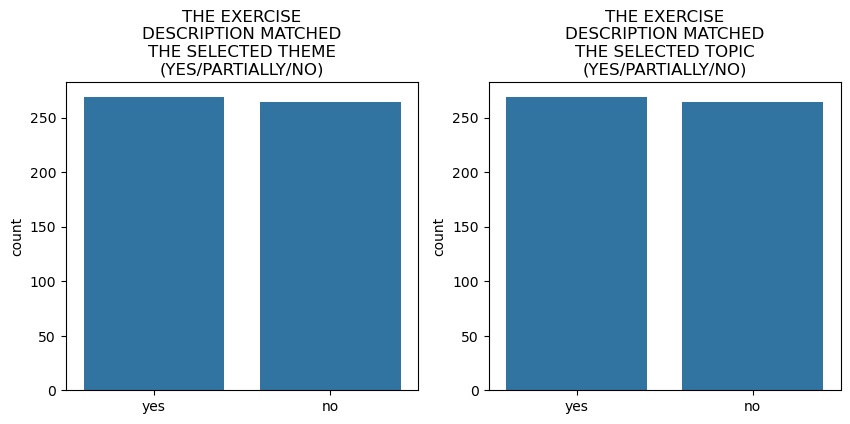

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

plot_distributions(concated_with_pruned, ax)

plt.show()

In [8]:
# Rename columns
final_df = concated_with_pruned.rename(columns={col_name: col_name.replace("/Partially", "") for col_name in EVAL_COLS}, errors="raise")

# Take relevant columns
final_df = final_df[[
    "title",
    "problemDescription",
    "exampleSolution",
    "theme",
    "topic",
    "concept",
    "The exercise description matched the selected theme (Yes/No)", 
    "The exercise description matched the selected topic (Yes/No)",
    "The exercise description matched the selected concept (Yes/No)"
]]

#final_df.head()

In [9]:
#final_df.to_csv("../../../data/augmented_dataset.csv", sep=";", index=False)

In [10]:
# Stats

stats = final_df.columns[-3:-1]
columns = pd.MultiIndex.from_tuples([
    ("yes", "Count"),
    ("yes", "Percentage"),
    ("no", "Count"),
    ("no", "Percentage"),
])

len_df = len(final_df)
count_yes = final_df[stats].eq("yes").sum()
count_partially = final_df[stats].eq("partially").sum()
count_no = final_df[stats].eq("no").sum()

data = list(zip(
    count_yes, 100 * count_yes / len_df,
    count_no, 100 * count_no / len_df
))

df_stats = pd.DataFrame(data, index=stats, columns=columns)
#df_stats # Stats match with the source

print(
    df_stats.to_latex(float_format="%.1f")
    .replace("tabular}", "tabularx}{\\textwidth}", 1)
    .replace("tabular}", "tabularx}")
)


#df[label].where(lambda x : x == "yes").dropna().count() / len(df[label])

\begin{tabularx}{\textwidth}{lrrrr}
\toprule
 & \multicolumn{2}{r}{yes} & \multicolumn{2}{r}{no} \\
 & Count & Percentage & Count & Percentage \\
\midrule
The exercise description matched the selected theme (Yes/No) & 269 & 50.5 & 264 & 49.5 \\
The exercise description matched the selected topic (Yes/No) & 269 & 50.5 & 264 & 49.5 \\
\bottomrule
\end{tabularx}

